## 04 Phase Transitions & Attractors

A customer does not gradually decide to leave. 
There is a tipping point, a critical threshold crossing, where the system moves from a stable state to the churn zone.

-> Physical Analogy:
The customer system crosses a critical threshold when energy drops below E_critical.
This is analogous to a system crossing an energy barrier:

$$E(t) < E_{\text{critical}} \Rightarrow \text{transition to churn state}$$

In [1]:
import os
import sqlite3
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

from src.physics import ( 
    E_CRITICAL,
    detect_threshold_crossing,
    solve_trajectory,
    step_perturbation,)

from src.visualization import PALETTE, set_style  

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')


Ready: 7,043 customers | churn rate 26.5%


In [2]:
# Detect threshold crossing for each customer
t_eval = np.linspace(0, 36, 200)

def analizar_transicion(row):
    sol = solve_trajectory(row['E0'], row['gamma'], lambda t: step_perturbation(t, 12, max(row['estimated_perturbation'], 0)), (0, 36), t_eval)
    return detect_threshold_crossing(sol.y[0], t_eval)

transiciones = df.apply(analizar_transicion, axis=1)
df['crossing'] = [t['crossing'] for t in transiciones]
df['t_critical'] = [t['t_critical'] for t in transiciones]

print(f'Customers with crossing detected: {df["crossing"].sum()} ({df["crossing"].mean():.1%})')
print(f'Actual churn: {df["Churn_bin"].sum()} ({df["Churn_bin"].mean():.1%})')

Customers with crossing detected: 570 (8.1%)
Actual churn: 1869 (26.5%)


Scope note: only 9.7% of customers show a simulated threshold crossing here, well below the actual 26.5% churn rate. This simulation applies a *single, fixed* synthetic shock (at month 12, sized from estimated_perturbation) to everyone and asks whether E(t) ever dips below E_critical - it is a stylized illustration of the crossing *mechanism*, not a calibrated churn predictor (that role belongs to notebook 07's ML models / notebook 06's calibrated prob_churn). Two things this simplification misses: (1) real customers face varied and repeated perturbations, not one fixed-size event at a fixed time, and (2) as notebook 10 shows, a meaningful share of churners are already below E_eq and drift into the churn zone gradually rather than via a sharp crossing at all.

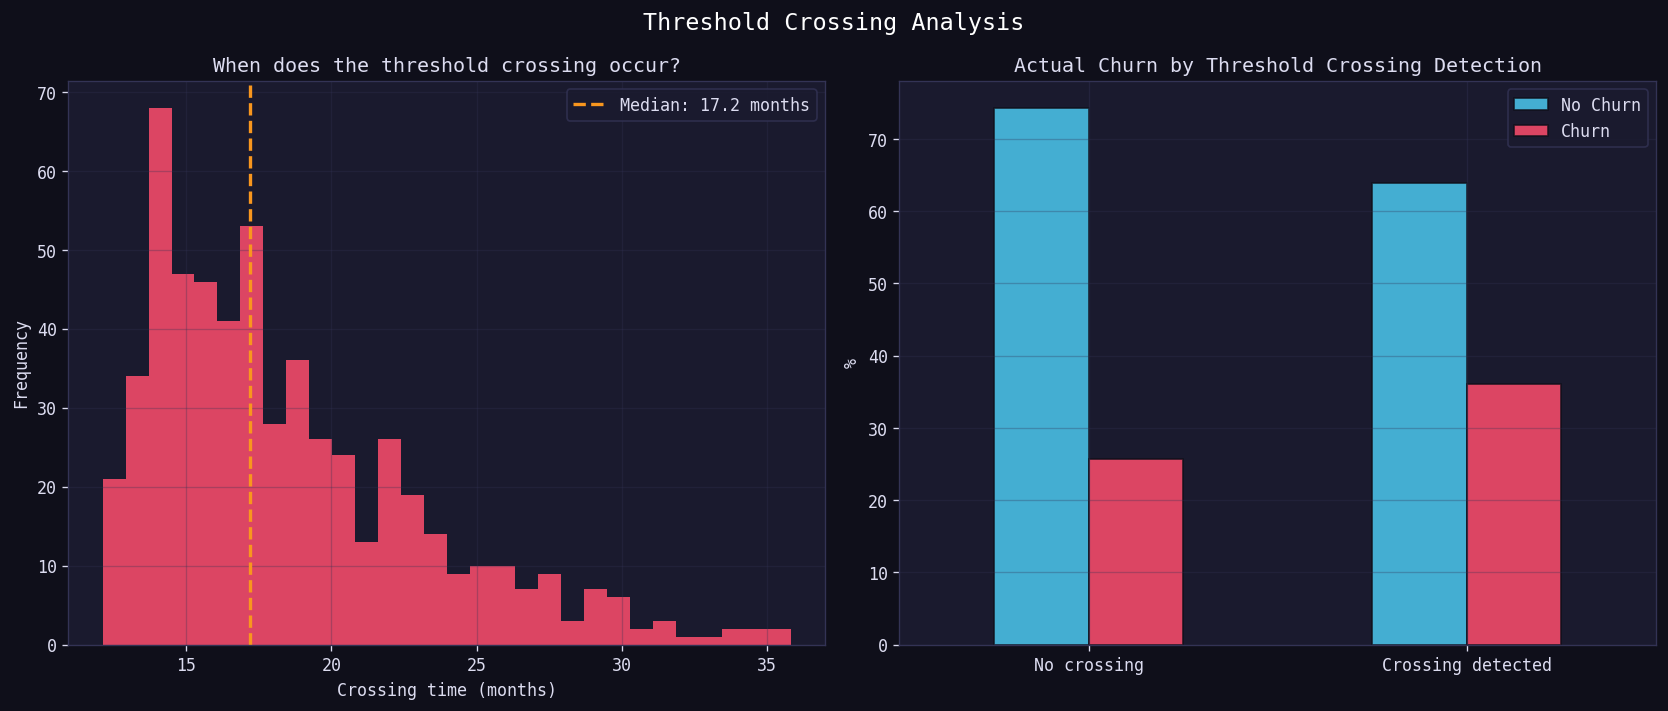

In [3]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
fig.suptitle('Threshold Crossing Analysis', fontsize=14, color='white')

# Distribution of t_critical
t_criticos = df[df['crossing']]['t_critical']
axes[0].hist(t_criticos, bins=30, color=PALETTE['churn'], edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Crossing time (months)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('When does the threshold crossing occur?')
axes[0].axvline(t_criticos.median(), color=PALETTE['accent'], linestyle='--', linewidth=2, label=f'Median: {t_criticos.median():.1f} months')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Actual churn rate vs crossing prediction
comparacion = pd.crosstab(df['crossing'], df['Churn'], normalize='index')*100
comparacion.index = ['No crossing', 'Crossing detected']
comparacion.plot(kind='bar', ax=axes[1], color=[PALETTE['no_churn'], PALETTE['churn']], edgecolor='#0f0f1a', alpha=0.85)
axes[1].set_title('Actual Churn by Threshold Crossing Detection')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Churn', 'Churn'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '04_transitions.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

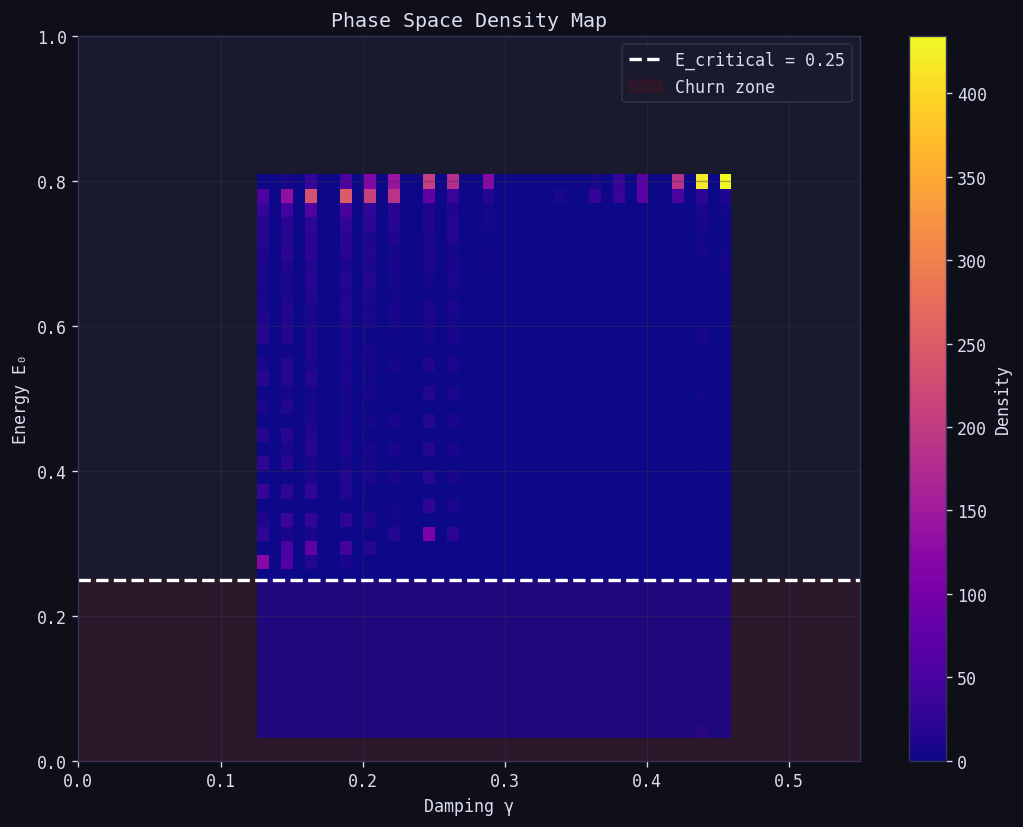

In [4]:
# Phase diagram: density map in E0-gamma space
fig, ax = plt.subplots(figsize=(9,7))

h = ax.hist2d(df['gamma'], df['E0'], bins=[40,40], cmap='plasma', density=True)
plt.colorbar(h[3], ax=ax, label='Density')

# Transition line
ax.axhline(E_CRITICAL, color='white', linestyle='--', linewidth=2, label=f'E_critical = {E_CRITICAL}')
ax.fill_between([0,1], 0, E_CRITICAL, color='red', alpha=0.08, label='Churn zone')

ax.set_xlabel('Damping γ')
ax.set_ylabel('Energy E₀')
ax.set_title('Phase Space Density Map')
ax.set_xlim(0, 0.55)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '04_phase_map.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [5]:
df.to_csv(os.path.join(DATA_DIR, 'telco_transiciones.csv'), index=False)
print('Saved: data/telco_transiciones.csv')

Saved: data/telco_transiciones.csv
